In [2]:
import pandas as pd
import numpy as np

countries = ["BN","KH","ID","LA","MY","MM","PH","SG","TH","VN"]

# 1. Electricity consumption per capita (kWh/person) from AEO8 Appendix C.8
# Only milestone years: 2022, 2030, 2050
elec_kwh = np.array([
    [10921, 10266, 8915],    # Brunei
    [742,   776,   1087],    # Cambodia
    [1055,  1194,  1757],    # Indonesia
    [1289,  1552,  2133],    # Lao PDR
    [4835,  5029,  6742],    # Malaysia
    [250,   263,   463],     # Myanmar
    [790,   882,   1101],    # Philippines
    [9861,  9108,  11324],   # Singapore
    [2880,  3066,  5191],    # Thailand
    [2446,  2916,  4734],    # Vietnam
], dtype=float)/1e3
# Unit: kWh/person (keep as kWh for TWh conversion later)

# 2. Actual population data (millions) from AEO8 (2005–2050, 5-year step)
pop_million = np.array([
    [0.4, 0.4, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],    
    [13.2, 16.8, 17.3, 18.1, 18.8, 19.4, 19.9, 20.3], 
    [228.8, 275.8, 282.0, 292.2, 300.9, 308.2, 313.7, 317.2], 
    [5.9, 7.5, 7.8, 8.3, 8.8, 9.1, 9.5, 9.8],    
    [25.9, 33.9, 35.0, 36.7, 38.1, 39.3, 40.2, 41.0], 
    [47.7, 54.2, 55.3, 57.0, 58.2, 59.1, 59.7, 59.9], 
    [86.3, 115.6, 120.9, 129.5, 137.6, 145.0, 151.8, 157.9], 
    [4.3, 5.6, 5.7, 5.9, 6.0, 6.0, 6.0, 5.9],    
    [65.8, 71.7, 72.0, 72.1, 71.7, 70.9, 69.6, 67.9], 
    [83.1, 98.2, 100.1, 102.7, 104.6, 105.9, 106.7, 107.0], 
], dtype=float) * 1e6  # convert to persons

pop_years = [2005, 2022, 2025, 2030, 2035, 2040, 2045, 2050]

# 3. Prepare target years: 2020 to 2050 in 5-year steps
target_years = np.arange(2020, 2051, 5)

# 4. Interpolate per-capita electricity (log-linear for CAGR style growth)
milestone_years = [2022, 2030, 2050]

elec_TWh = pd.DataFrame(index=countries, columns=target_years)

for i, country in enumerate(countries):
    # Per-capita consumption
    kwh_values = elec_kwh[i]
    log_vals = np.log(kwh_values)
    
    # Interpolate per-capita to target years
    log_interp = np.interp(target_years, milestone_years, log_vals)
    kwh_interp = np.exp(log_interp)
    
    # Interpolate population to target years
    pop_interp = np.interp(target_years, pop_years, pop_million[i])
    
    # Compute demand in TWh: kWh/person * persons / 1e6 -> TWh
    twh = kwh_interp * pop_interp / 1e6
    elec_TWh.loc[country] = np.round(twh, 4)

print("5-yearly Electricity Demand (TWh):")
print(elec_TWh)



5-yearly Electricity Demand (TWh):
        2020      2025      2030      2035      2040      2045      2050
BN    4.3684    5.3353     5.133    4.9551    4.7833    4.6175    4.4575
KH   12.1513   13.0541   14.0456   15.8713   17.8175   19.8834   22.0661
ID  285.1355  311.6438  348.8868  395.7021  446.3964  500.4312  557.3204
LA    9.4249   10.7792   12.8816   14.7877    16.557    18.715   20.9034
MY  159.3559    171.74  184.5643  206.1738  228.8378  251.8767   276.422
MM   13.3588   14.0903    14.991   17.6313   20.6232   23.9966   27.7337
PH   88.6008   99.5392   114.219  128.2823  142.8881  158.1173  173.8479
SG   53.7134   54.5581   53.7372   57.7057   60.9344   64.3438   66.8116
TH  204.4969   212.284  221.0586  250.7616  282.8511   316.731  352.4689
VN   235.852  261.5259  299.4732  344.2939   393.463  447.4891   506.538


In [3]:
import pandas as pd
import xarray as xr
import numpy as np
from pathlib import Path

countries = ["BN","KH","ID","LA","MY","MM","PH","SG","TH","VN"]
gegis_years = [2030, 2040, 2050]
target_years = np.arange(2020, 2051, 5)

data_path = Path("../data/ssp2-2.6")  # adjust to your folder
era = "era5_2018"
continent = "Asia.nc"

# 1. Load and aggregate GEGIS demand (TWh/year)
gegis_TWh = pd.DataFrame(index=countries, columns=gegis_years, dtype=float)

for year in gegis_years:
    gegis_file = data_path / f"{year}" / era / continent
    ds = xr.open_dataset(gegis_file)
    df = ds.to_dataframe().reset_index()
    yearly_TWh = df.groupby("region_code")["Electricity demand"].sum() / 1e6
    gegis_TWh[year] = yearly_TWh.reindex(countries)
# --- Substitute Laos (LA) demand with Myanmar (MM) ---
gegis_TWh.loc["LA"] = gegis_TWh.loc["MM"]
print("Raw GEGIS baseline TWh:\n", gegis_TWh)

# 2. Interpolate to 5-year steps (log-linear per country)
interp_TWh = pd.DataFrame(index=countries, columns=target_years, dtype=float)

for country in countries:
    vals = gegis_TWh.loc[country].values.astype(float)
    log_vals = np.log(vals)
    interp_logs = np.interp(target_years, gegis_years, log_vals)  # 1-D interpolation
    interp_TWh.loc[country] = np.exp(interp_logs)

print("\nInterpolated 5-yearly GEGIS Demand (TWh):\n", interp_TWh)



Raw GEGIS baseline TWh:
           2030        2040        2050
BN    5.444387    6.725891    8.632414
KH    9.129645   11.224307   14.625071
ID  312.567890  392.969088  509.278867
LA   23.003356   28.238440   36.131315
MY  193.128147  236.155150  302.661342
MM   23.003356   28.238440   36.131315
PH  112.667137  138.489838  178.781554
SG   66.360425   81.720002  104.561282
TH  274.564234  340.951639  427.414689
VN  211.904265  261.766372  336.211314

Interpolated 5-yearly GEGIS Demand (TWh):
           2020        2025        2030        2035        2040        2045  \
BN    5.444387    5.444387    5.444387    6.051310    6.725891    7.619755   
KH    9.129645    9.129645    9.129645   10.122941   11.224307   12.812349   
ID  312.567890  312.567890  312.567890  350.470425  392.969088  447.359868   
LA   23.003356   23.003356   23.003356   25.486837   28.238440   31.942010   
MY  193.128147  193.128147  193.128147  213.560779  236.155150  267.348152   
MM   23.003356   23.003356   23.00

In [4]:
import yaml

# --- Assume you already have ---
# elec_TWh: AEO8-based target demand (TWh)
# interp_TWh: GEGIS baseline demand (TWh), interpolated to the same target_years
# countries: list of country codes
# target_years: np.arange(2020, 2051, 5)

# 1. Compute scale factors
scale_df = elec_TWh.astype(float) / interp_TWh.astype(float)
scale_df = scale_df.round(3)  # optional rounding

print("\nScale factors:\n", scale_df)

# 2. Convert to nested dictionary {year: {country: scale}}
scale_dict = {}
for year in target_years:
    scale_dict[int(year)] = {country: float(scale_df.loc[country, year])
                             for country in countries}

# 3. Save to YAML file
with open("myopic_scale.yaml", "w") as f:
    yaml.dump(scale_dict, f, default_flow_style=False)

print("\nYAML file 'myopic_scale.yaml' created.")



Scale factors:
      2020   2025   2030   2035   2040   2045   2050
BN  0.802  0.980  0.943  0.819  0.711  0.606  0.516
KH  1.331  1.430  1.538  1.568  1.587  1.552  1.509
ID  0.912  0.997  1.116  1.129  1.136  1.119  1.094
LA  0.410  0.469  0.560  0.580  0.586  0.586  0.579
MY  0.825  0.889  0.956  0.965  0.969  0.942  0.913
MM  0.581  0.613  0.652  0.692  0.730  0.751  0.768
PH  0.786  0.883  1.014  1.027  1.032  1.005  0.972
SG  0.809  0.822  0.810  0.784  0.746  0.696  0.639
TH  0.745  0.773  0.805  0.820  0.830  0.830  0.825
VN  1.113  1.234  1.413  1.462  1.503  1.508  1.507

YAML file 'myopic_scale.yaml' created.


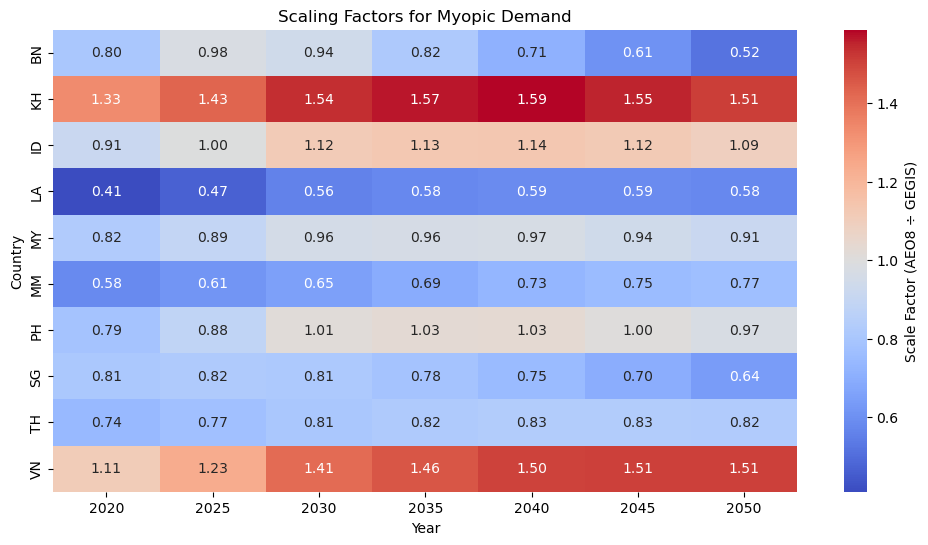

In [6]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(scale_df, annot=True, fmt=".2f", cmap="coolwarm",
            cbar_kws={'label': 'Scale Factor (AEO8 ÷ GEGIS)'})
plt.title("Scaling Factors for Myopic Demand")
plt.xlabel("Year")
plt.ylabel("Country")
plt.show()


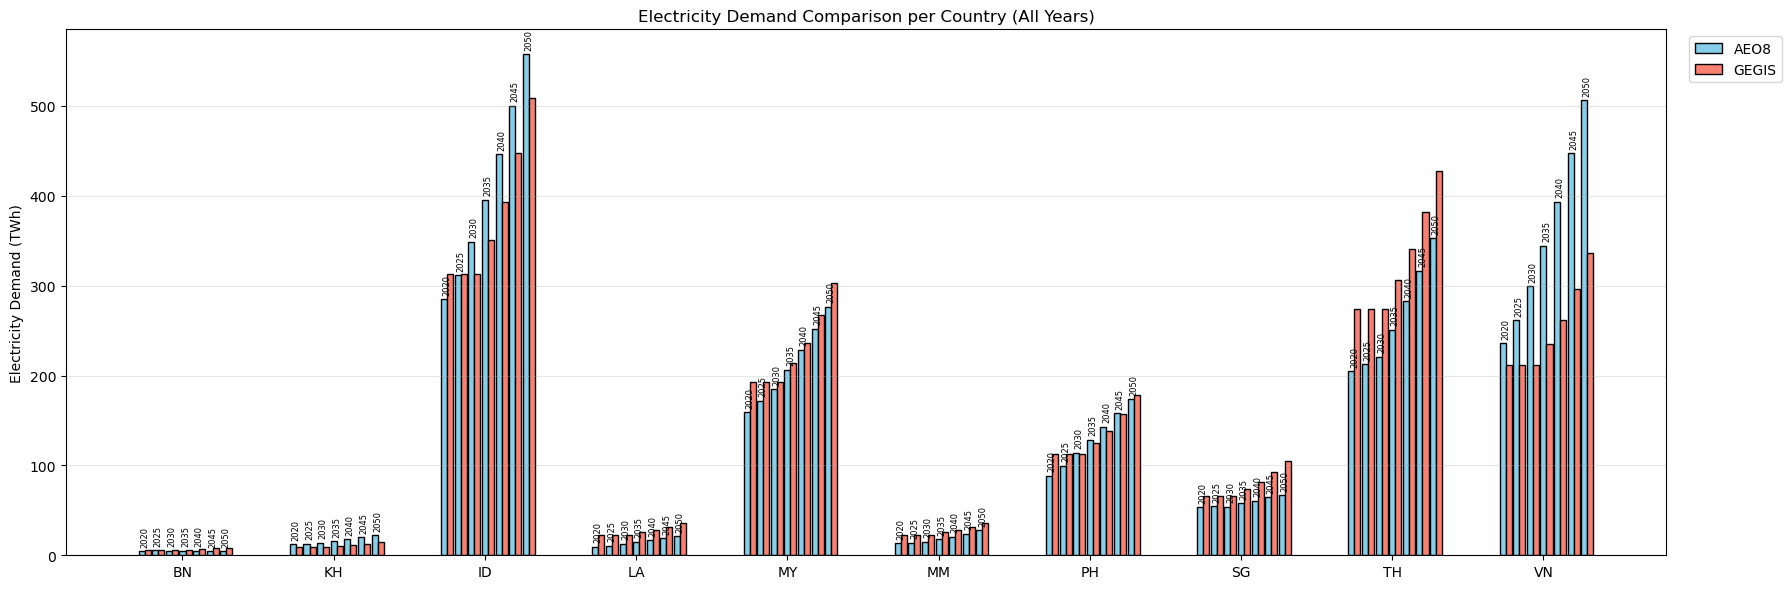

In [12]:
import matplotlib.pyplot as plt
import numpy as np

years = target_years
n_years = len(years)
x = np.arange(len(countries))  # base position for each country
bar_width = 0.04               # thinner bars to fit

fig, ax = plt.subplots(figsize=(18, 6))

for i, year in enumerate(years):
    offset = (i - (n_years-1)/2) * (2*bar_width + 0.01)
    
    # Bars
    ax.bar(x + offset, elec_TWh[year], bar_width, color='skyblue', edgecolor='k', label=f"AEO8 {year}" if i==0 else "")
    ax.bar(x + offset + bar_width, interp_TWh[year], bar_width, color='salmon', edgecolor='k', label=f"GEGIS {year}" if i==0 else "")
    
    # Annotate year above the cluster center (optional)
    for j, xpos in enumerate(x + offset + bar_width/2):
        ax.text(xpos, elec_TWh[year].iloc[j] + 5, str(year), ha='center', va='bottom', fontsize=6, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(countries)
ax.set_ylabel('Electricity Demand (TWh)')
ax.set_title('Electricity Demand Comparison per Country (All Years)')
ax.grid(axis='y', alpha=0.3)

# Simplified legend for datasets only
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='skyblue', edgecolor='k', label='AEO8'),
    Patch(facecolor='salmon', edgecolor='k', label='GEGIS')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()




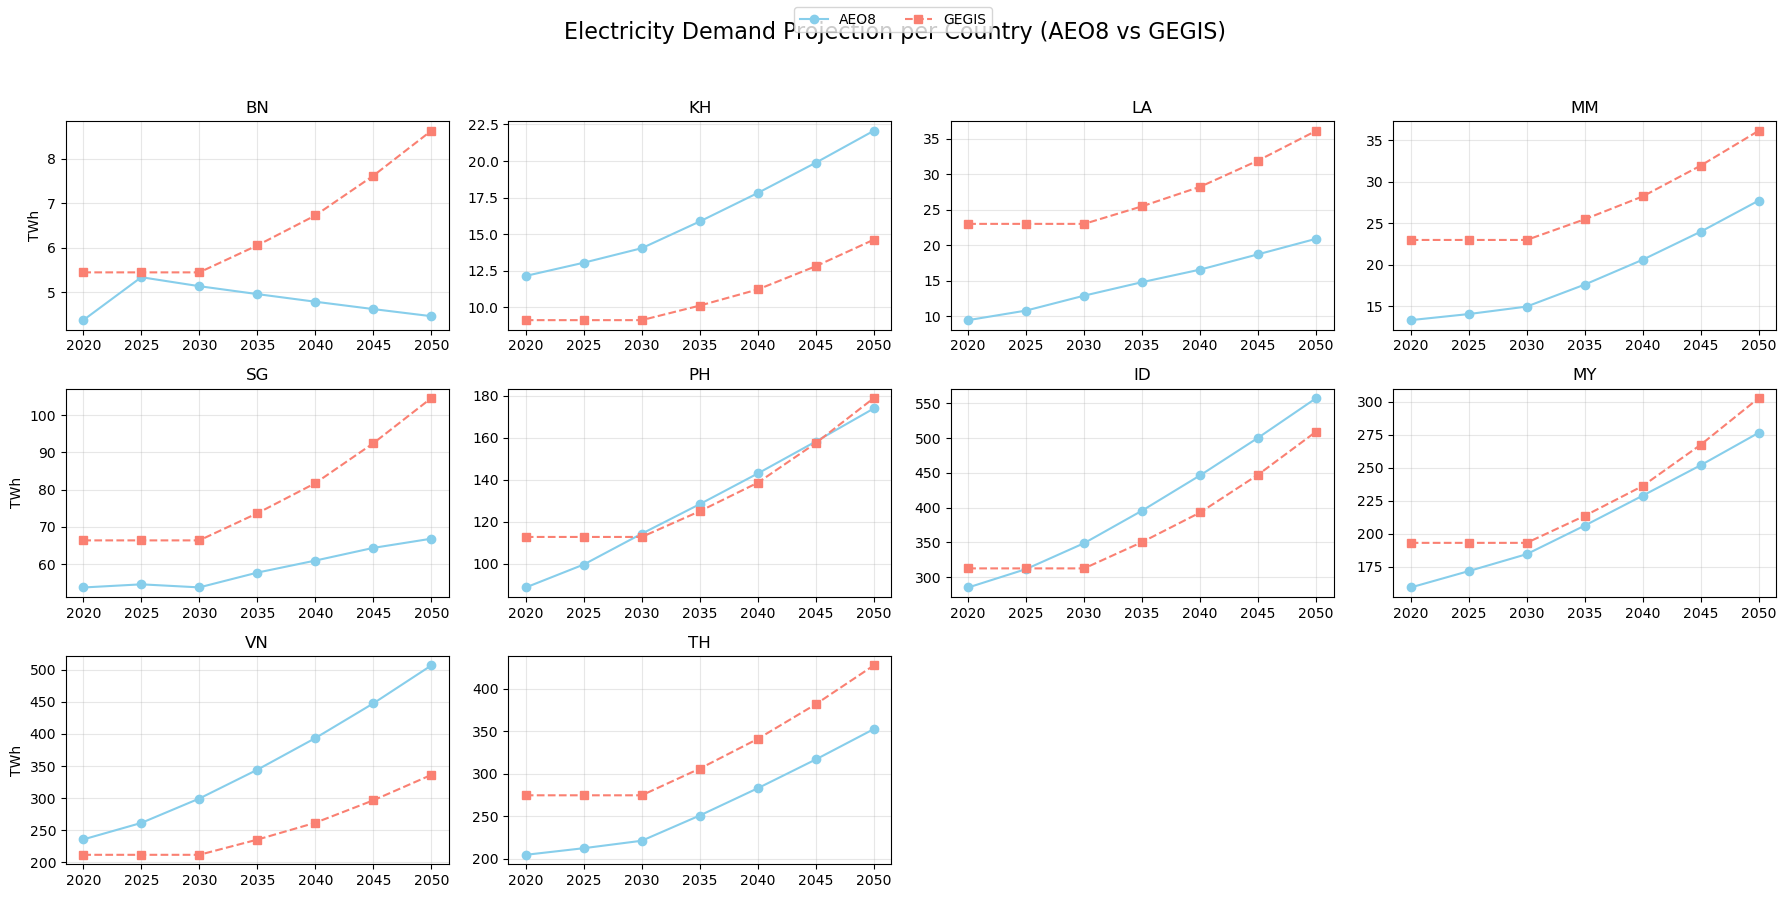

In [17]:
import matplotlib.pyplot as plt

# Group definitions by demand scale
groups = [
    ["BN", "KH", "LA", "MM"],   # small
    ["SG", "PH"],               # medium
    ["ID", "MY", "VN", "TH"]    # large
]

fig, axes = plt.subplots(3, 4, figsize=(18, 9))  # 3 rows, 4 columns
axes = axes.flatten()

group_titles = ["Small Demand (BN, KH, LA, MM)", 
                "Medium Demand (SG, PH)", 
                "Large Demand (ID, MY, VN, TH)"]

# Flattened indexing to fill row by row
plot_idx = 0
for g_idx, group in enumerate(groups):
    for country in group:
        ax = axes[plot_idx]
        ax.plot(target_years, elec_TWh.loc[country], color='skyblue', marker='o', label='AEO8')
        ax.plot(target_years, interp_TWh.loc[country], color='salmon', marker='s', linestyle='--', label='GEGIS')
        ax.set_title(country)
        ax.grid(alpha=0.3)
        if plot_idx % 4 == 0:  # first column of each row
            ax.set_ylabel("TWh")
        plot_idx += 1

# Remove empty subplots if fewer than 12
for i in range(plot_idx, len(axes)):
    fig.delaxes(axes[i])

# Add a global title and one legend
fig.suptitle("Electricity Demand Projection per Country (AEO8 vs GEGIS)", fontsize=16)
fig.legend(['AEO8','GEGIS'], loc='upper center', ncol=4)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

